In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [31]:
data = pd.read_csv('American_Housing_Data_20231209.csv')
data

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,2626 27TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,3215 32ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,3257 22ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,3711 26TH PL W APT 102,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [32]:
data.head()

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601


In [33]:
data.tail()

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
39976,98199,2495000.0,4,4,3380,2626 27TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,3215 32ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,3257 22ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,3711 26TH PL W APT 102,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39980,98199,1150000.0,3,3,2840,2911 25TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [34]:
data.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
Address                     object
City                        object
State                       object
Zip Code Population          int64
Zip Code Density           float64
County                      object
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [35]:
data.columns

Index(['Zip Code', 'Price', 'Beds', 'Baths', 'Living Space', 'Address', 'City',
       'State', 'Zip Code Population', 'Zip Code Density', 'County',
       'Median Household Income', 'Latitude', 'Longitude'],
      dtype='object')

In [36]:
data.drop('Address', axis=1, inplace=True)

In [37]:
data

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [38]:
le_city = LabelEncoder()
data['City'] = le_city.fit_transform(data['City'])

le_state = LabelEncoder()
data['State'] = le_state.fit_transform(data['State'])

le_county = LabelEncoder()
data['County'] = le_county.fit_transform(data['County'])

In [39]:
data

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223


In [40]:
data.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
City                         int64
State                        int64
Zip Code Population          int64
Zip Code Density           float64
County                       int64
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [41]:
data.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    2
Latitude                   0
Longitude                  0
dtype: int64

In [42]:
data = data.dropna()

In [43]:
data.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    0
Latitude                   0
Longitude                  0
dtype: int64

In [44]:
data.shape

(39979, 13)

{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d2447c50>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d2447ed0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d2447b10>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d27f4190>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d27f42d0>],
 'means': []}

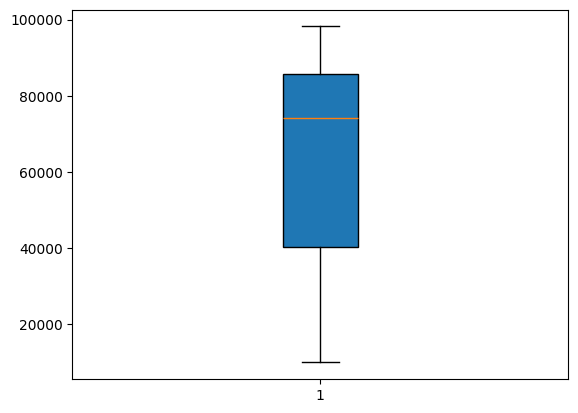

In [45]:
plt.boxplot(data['Zip Code'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d282a5d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d282a850>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d282a490>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d282aad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d282ac10>],
 'means': []}

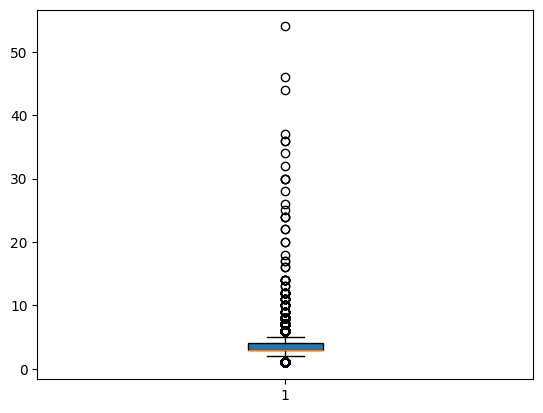

In [46]:
plt.boxplot(data['Beds'], patch_artist=True)

In [47]:
Q1 = data.Beds.quantile(0.25)
Q3 = data.Beds.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

upper_index = np.where(data['Beds'] >= upper)[0]
lower_index = np.where(data['Beds'] <= lower)[0]

data.drop(index=upper_index, inplace=True)
data.drop(index=lower_index, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\3869557940.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index=upper_index, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1220\3869557940.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index=lower_index, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d28816d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d2881950>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d2881590>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d2881bd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d2881d10>],
 'means': []}

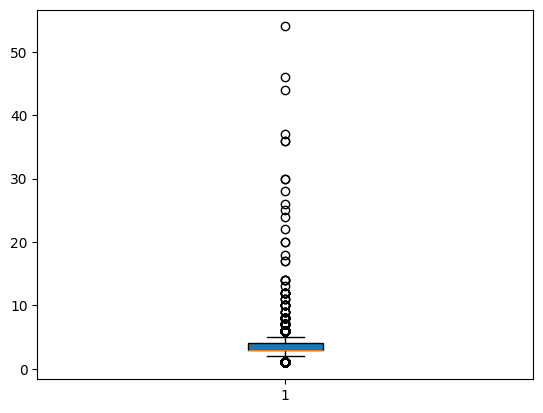

In [48]:
plt.boxplot(data['Beds'], patch_artist=True)

In [49]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d32807d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d3280a50>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d3280690>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d3280cd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d3280e10>],
 'means': []}

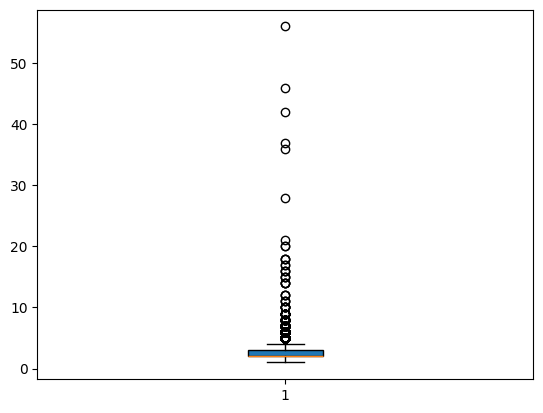

In [50]:
plt.boxplot(data['Baths'], patch_artist=True)

In [51]:
Q1 = data.Baths.quantile(0.25)
Q3 = data.Baths.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

upper_index = np.where(data['Baths'] >= upper)[0]
lower_index = np.where(data['Baths'] <= lower)[0]

data.drop(index=upper_index, inplace=True)
data.drop(index=lower_index, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\3705115052.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index=upper_index, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1220\3705115052.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index=lower_index, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d32af890>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d32afb10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d32af750>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d32afd90>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d32afed0>],
 'means': []}

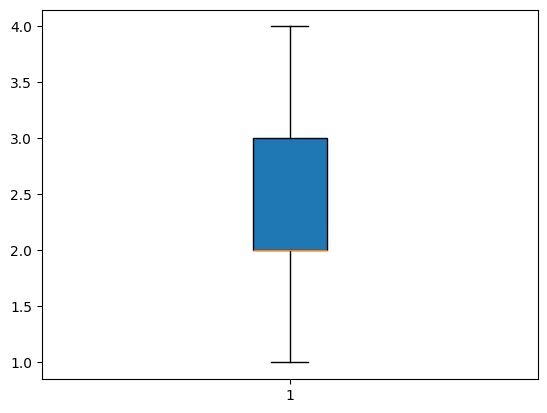

In [52]:
plt.boxplot(data['Baths'], patch_artist=True)

In [53]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d332f110>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d332f390>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d332efd0>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d332f610>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d332f750>],
 'means': []}

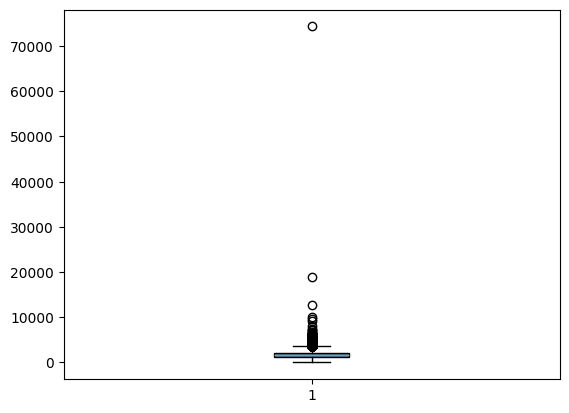

In [54]:
plt.boxplot(data['Living Space'], patch_artist=True)

In [55]:
Q1 = data['Living Space'].quantile(0.25)
Q3 = data['Living Space'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

upper_index = np.where(data['Living Space'] >= upper)[0]
lower_index = np.where(data['Living Space'] <= lower)[0]

data.drop(index=upper_index, inplace=True)
data.drop(index=lower_index, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\3175937590.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index=upper_index, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1220\3175937590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index=lower_index, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x2d6d314f110>,
 'caps': [<matplotlib.lines.Line2D at 0x2d6d314f390>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2d6d314efd0>],
 'medians': [<matplotlib.lines.Line2D at 0x2d6d314f610>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d6d314f750>],
 'means': []}

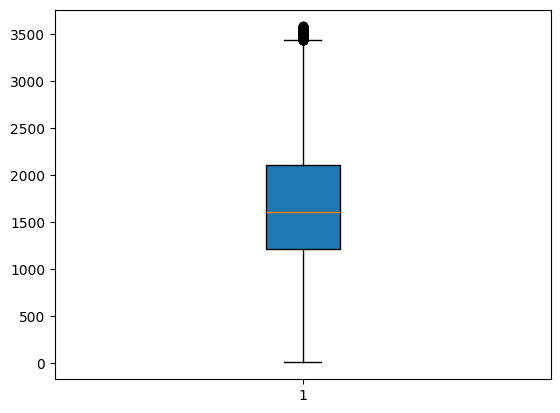

In [56]:
plt.boxplot(data['Living Space'], patch_artist=True)

In [57]:
correlation = data.corr()
correlation

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
Zip Code,1.000000,0.197745,-0.023917,-0.031047,0.029796,0.085122,-0.216501,-0.021712,-0.085692,-0.049669,0.170649,-0.065830,-0.940289
Price,0.197745,1.000000,0.132703,0.344000,0.359976,0.149042,-0.229495,-0.024030,0.275123,0.042490,0.569874,-0.041532,-0.291584
Beds,-0.023917,0.132703,1.000000,0.479569,0.629682,-0.047917,0.098184,0.085161,-0.181942,0.002083,-0.041854,-0.057906,0.063724
Baths,-0.031047,0.344000,0.479569,1.000000,0.698029,-0.036083,0.062851,0.033027,-0.094950,-0.051271,0.231999,-0.124495,0.043578
Living Space,0.029796,0.359976,0.629682,0.698029,1.000000,-0.043104,0.091847,-0.025710,-0.166214,-0.027900,0.213579,-0.088977,0.012403
City,0.085122,0.149042,-0.047917,-0.036083,-0.043104,1.000000,-0.121734,-0.035614,0.094891,0.303329,0.143669,0.121364,-0.182288
State,-0.216501,-0.229495,0.098184,0.062851,0.091847,-0.121734,1.000000,0.038556,-0.144532,0.081721,-0.128041,0.041908,0.343401
Zip Code Population,-0.021712,-0.024030,0.085161,0.033027,-0.025710,-0.035614,0.038556,1.000000,0.103975,-0.061944,-0.100066,-0.099259,-0.020991
Zip Code Density,-0.085692,0.275123,-0.181942,-0.094950,-0.166214,0.094891,-0.144532,0.103975,1.000000,-0.010972,0.186300,0.195754,0.005078
County,-0.049669,0.042490,0.002083,-0.051271,-0.027900,0.303329,0.081721,-0.061944,-0.010972,1.000000,0.035500,-0.002735,0.049165


<Axes: >

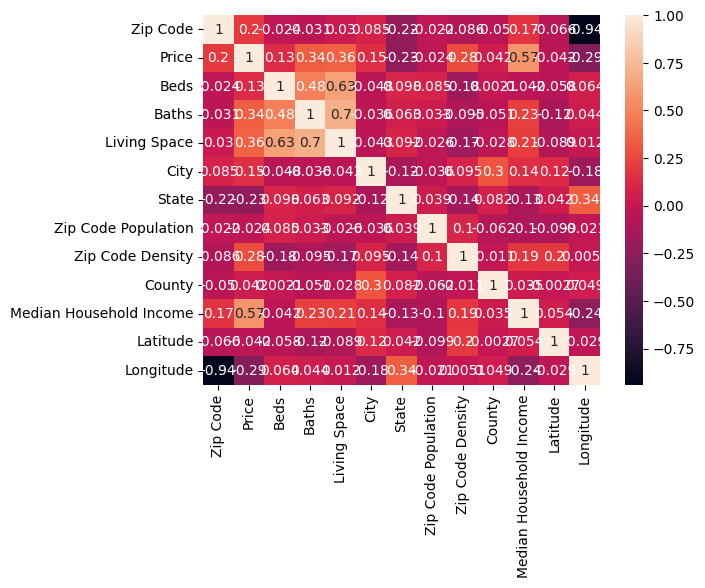

In [58]:
sns.heatmap(correlation, annot=True)

In [59]:
data.drop('Zip Code Population', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\1127822671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Zip Code Population', axis=1, inplace=True)


In [60]:
data.drop('County', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\2766149167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('County', axis=1, inplace=True)


In [61]:
data.drop('Latitude', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\348445166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Latitude', axis=1, inplace=True)


In [62]:
data.drop('Zip Code', axis=1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1220\2935761609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Zip Code', axis=1, inplace=True)


In [63]:
correlation = data.corr()
correlation

,Price,Beds,Baths,Living Space,City,State,Zip Code Density,Median Household Income,Longitude
Price,1.000000,0.132703,0.344000,0.359976,0.149042,-0.229495,0.275123,0.569874,-0.291584
Beds,0.132703,1.000000,0.479569,0.629682,-0.047917,0.098184,-0.181942,-0.041854,0.063724
Baths,0.344000,0.479569,1.000000,0.698029,-0.036083,0.062851,-0.094950,0.231999,0.043578
Living Space,0.359976,0.629682,0.698029,1.000000,-0.043104,0.091847,-0.166214,0.213579,0.012403
City,0.149042,-0.047917,-0.036083,-0.043104,1.000000,-0.121734,0.094891,0.143669,-0.182288
State,-0.229495,0.098184,0.062851,0.091847,-0.121734,1.000000,-0.144532,-0.128041,0.343401
Zip Code Density,0.275123,-0.181942,-0.094950,-0.166214,0.094891,-0.144532,1.000000,0.186300,0.005078
Median Household Income,0.569874,-0.041854,0.231999,0.213579,0.143669,-0.128041,0.186300,1.000000,-0.243705
Longitude,-0.291584,0.063724,0.043578,0.012403,-0.182288,0.343401,0.005078,-0.243705,1.000000


<Axes: >

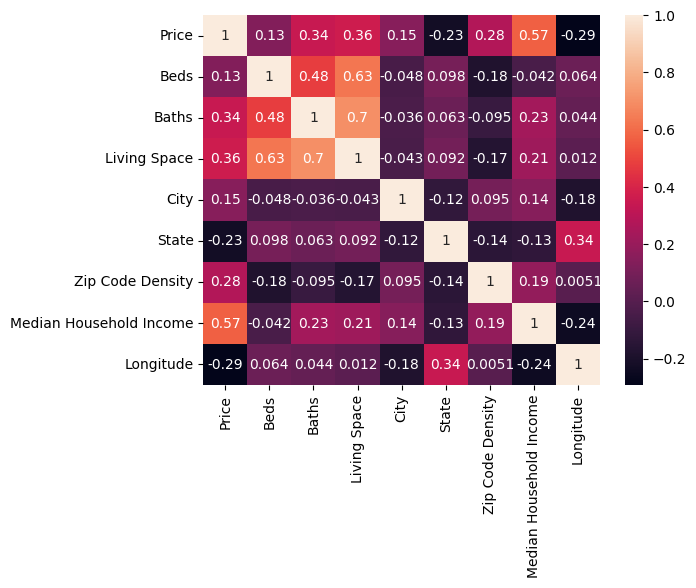

In [65]:
sns.heatmap(correlation, annot=True)

In [66]:
x = data.drop('Price', axis=1) #features
y = data['Price'] #target

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

In [77]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [78]:
model.score(x_test, y_test)

0.5072809240153493

In [79]:
model.score(x_train, y_train)

0.491380940838252

In [80]:
y_pred = model.predict(x_test)

In [81]:
pd.DataFrame({'True values':y_test,'Predicted values':y_pred})

,True values,Predicted values
29561,1000000.0,692578.929831
152,549000.0,432336.639939
22276,1198000.0,934726.896957
20374,635000.0,640511.049117
18558,440000.0,610175.328261
...,...,...
34183,429900.0,542726.616148
3045,154250.0,116006.225854
33289,550000.0,505932.521388
33975,216000.0,223966.826766


In [82]:
mean_absolute_error(y_test, y_pred)

182535.24278243943

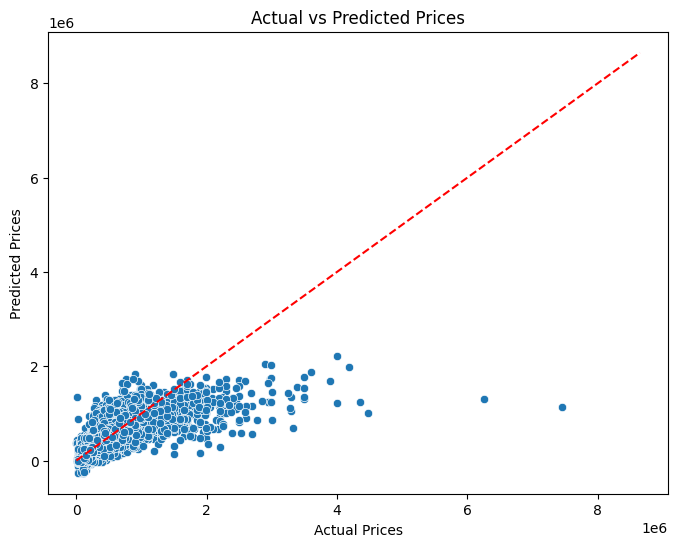

In [83]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.plot([y.min(), y.max()],[y.min(),y.max()],'r--')

In [84]:
residuals = y_test - y_pred

Text(0.5, 1.0, 'Residuals vs Predicted')

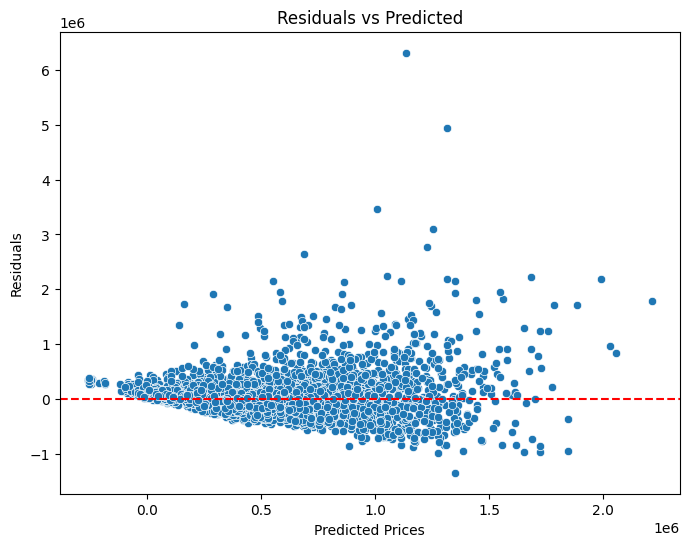

In [86]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

Text(0.5, 1.0, 'Residuals Distribution')

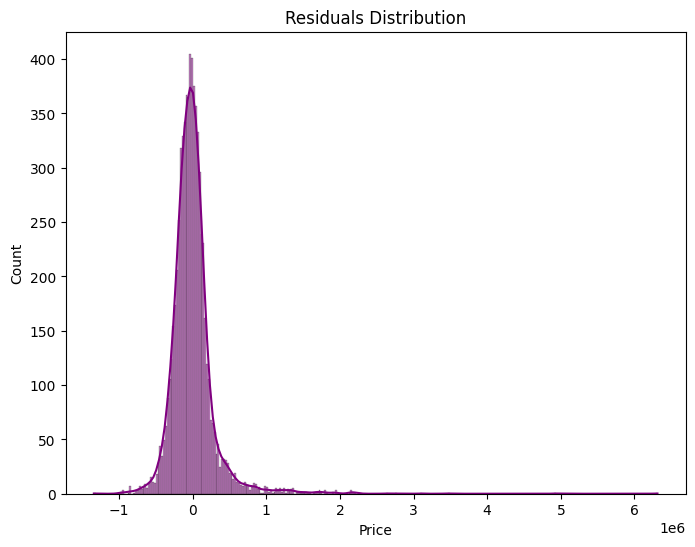

In [87]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Residuals Distribution')

In [88]:
print('RMSE: ',np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE:  303914.01478623314
